# Simple aggregated-network damage study

This is a simplified version of the damage notebook.

The logic is deliberately kept simple:

1. Load or generate an aggregated adjacency matrix `A_agg` and positions `positions_agg`.
2. Generate a matched `networkx.random_geometric_graph` null model.
3. Assign excitatory/inhibitory identity **once**, in the same ordered way as your original `Agregation.ipynb`: first 80% excitatory, last 20% inhibitory.
4. Apply damage while preserving original survivor order.
5. Compute structural metrics correctly, especially the giant component relative to the **original network size**.
6. Simulate Izhikevich dynamics and plot rasters in the same spirit as your original notebook.

The important invariant is:

```python
survivors = np.sort(survivors)
A_damaged = A_original[np.ix_(survivors, survivors)]
cell_types_damaged = cell_types_original[survivors]
positions_damaged = positions_original[survivors]
```

That is what keeps topology, position, and E/I identity aligned after damage.


In [39]:
# ============================================================
# Imports and global parameters
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx
from pathlib import Path

SEED = 42

rng = np.random.default_rng(SEED)

# Spatial domain. Match this to your aggregation notebook.
L = 3.0

# Izhikevich parameters, matching your current notebook logic.
EXCITATORY_FRACTION = 0.8
SIM_TIME = 3000
MAX_EXC_WEIGHT = 8   # change to 8.5 if that is the version you want
MAX_INH_WEIGHT = 0.5
NOISE_EXC = 3.0
NOISE_INH = 2.0

# Damage experiment parameters.
DAMAGE_FRACTIONS = np.round(np.arange(0.0, 0.2, 0.05), 2)
REPEATS_RANDOM = 10      # only random attack needs repeats
BIN_SIZE = 20
BETWEENNESS_K = 200  # approximate betweenness sources; set None for exact but slower


# 1. Basic utilities

In [40]:
def clean_adjacency(A):
    """Return a clean symmetric 0/1 adjacency matrix with no self-loops."""
    A = np.asarray(A)
    A = (A > 0).astype(int)
    if A.shape[0] != A.shape[1]:
        raise ValueError("A must be square.")
    A = np.maximum(A, A.T)
    np.fill_diagonal(A, 0)
    return A


def graph_to_adjacency(G, nodelist=None):
    if nodelist is None:
        nodelist = sorted(G.nodes())
    return nx.to_numpy_array(G, nodelist=nodelist, dtype=int)


def basic_network_summary(A, name="network"):
    A = clean_adjacency(A)
    G = nx.from_numpy_array(A)
    degrees = np.array([d for _, d in G.degree()])
    print(f"{name}")
    print("-" * len(name))
    print("nodes:", A.shape[0])
    print("edges:", G.number_of_edges())
    print("mean degree:", degrees.mean() if len(degrees) else 0)
    print("density:", nx.density(G))
    print("connected:", nx.is_connected(G) if A.shape[0] > 0 else False)
    print()


# 2. Load the aggregated network

Recommended workflow from your aggregation notebook:

```python
np.save("A_GC.npy", A)
np.save("positions_GC.npy", positions)
```

The notebook below first tries to use variables already in memory (`A_agg`, `positions_agg`). Then it tries to load `A_GC.npy` and `positions_GC.npy`. If neither exists, it generates a small test aggregated network so the notebook can still run.


In [41]:
A_agg = np.load("A_GC.npy") 
positions_agg = np.load("positions_GC.npy") 

# ---- Load ----
if "A_agg" in globals():
    A_agg = clean_adjacency(A_agg)
    if "positions_agg" in globals():
        positions_agg = np.asarray(positions_agg)
    else:
        positions_agg = None
    print("Using existing A_agg from memory.")

elif Path("A_GC.npy").exists():
    A_agg = clean_adjacency(np.load("A_GC.npy"))
    positions_agg = np.load("positions_GC.npy") if Path("positions_GC.npy").exists() else None
    print("Loaded A_GC.npy from disk.")


basic_network_summary(A_agg, "Aggregated network")
if positions_agg is not None:
    print("positions_agg shape:", positions_agg.shape)


Using existing A_agg from memory.
Aggregated network
------------------
nodes: 993
edges: 16995
mean degree: 34.229607250755286
density: 0.03450565247051944
connected: True

positions_agg shape: (993, 2)


# 3. Matched random geometric graph

This uses `nx.random_geometric_graph` and fits the radius so that the random geometric graph has approximately the same number of edges as `A_agg`.

The positions are returned as an `(N, 2)` matrix, not as a NetworkX dictionary, so plotting remains simple.


In [42]:
def generate_random_geometric_matching_edges(A_ref, L=3.0, seed=42, max_iter=35):
    A_ref = clean_adjacency(A_ref)
    N = A_ref.shape[0]
    M_target = int(A_ref.sum() // 2)

    rng = np.random.default_rng(seed)
    positions = rng.uniform(-L/2, L/2, size=(N, 2))
    pos_dict = {i: positions[i] for i in range(N)}

    low, high = 0.0, np.sqrt(2) * L
    best_G = None
    best_r = None
    best_error = np.inf

    for _ in range(max_iter):
        r = 0.5 * (low + high)
        G = nx.random_geometric_graph(N, r, pos=pos_dict)
        m = G.number_of_edges()
        error = abs(m - M_target)

        if error < best_error:
            best_G = G
            best_r = r
            best_error = error

        if m < M_target:
            low = r
        else:
            high = r

    A_rgg = graph_to_adjacency(best_G, nodelist=range(N))
    print("Random geometric graph")
    print("target edges:", M_target)
    print("obtained edges:", best_G.number_of_edges())
    print("fitted radius:", best_r)
    print()
    return A_rgg, positions, best_r


A_rgg, positions_rgg, r_rgg = generate_random_geometric_matching_edges(A_agg, L=L, seed=SEED)
basic_network_summary(A_rgg, "Random geometric null")


Random geometric graph
target edges: 16995
obtained edges: 16995
fitted radius: 0.3294544969643207

Random geometric null
---------------------
nodes: 993
edges: 16995
mean degree: 34.229607250755286
density: 0.03450565247051944
connected: True



# 4. Plot networks and adjacency matrices

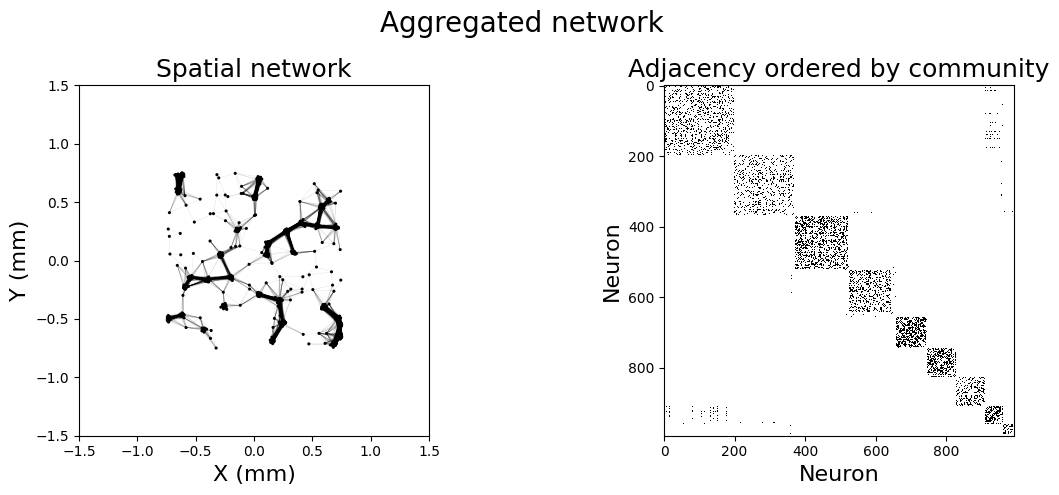

communities: 10
community sizes: [199, 172, 152, 134, 87, 83, 81, 50, 30, 5]


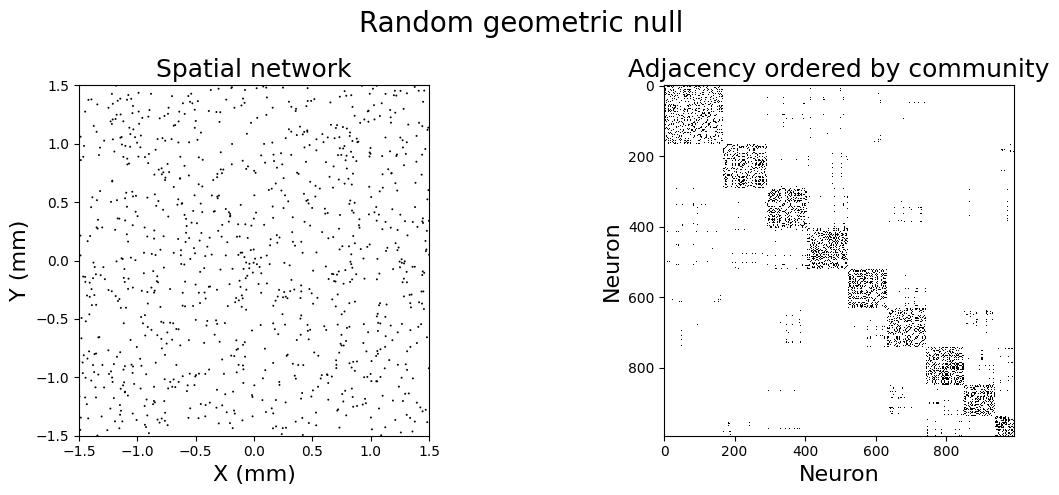

communities: 9
community sizes: [167, 123, 115, 115, 111, 110, 107, 89, 56]


In [43]:
def community_ordered_adjacency(A, seed=42):
    A = clean_adjacency(A)
    G = nx.from_numpy_array(A)
    if G.number_of_edges() == 0:
        return A, [set(range(A.shape[0]))], list(range(A.shape[0]))

    communities = nx.community.louvain_communities(G, seed=seed)
    communities = sorted(communities, key=len, reverse=True)

    ordered_nodes = []
    for comm in communities:
        ordered_nodes.extend(sorted(comm))

    A_ordered = A[np.ix_(ordered_nodes, ordered_nodes)]
    return A_ordered, communities, ordered_nodes


def plot_network_and_adjacency(A, positions, title="network", L=3.0, draw_edges=True,
                               node_size=5, edge_alpha=0.15, seed=42):
    A = clean_adjacency(A)
    positions = np.asarray(positions)
    if positions.shape != (A.shape[0], 2):
        raise ValueError(f"positions must have shape {(A.shape[0], 2)}, got {positions.shape}")

    A_ordered, communities, _ = community_ordered_adjacency(A, seed=seed)

    fig, axes = plt.subplots(1, 2, figsize=(12, 5), gridspec_kw={"width_ratios": [1, 1]})

    ax = axes[0]
    if draw_edges:
        rows, cols = np.where(np.triu(A, 1) > 0)
        for i, j in zip(rows, cols):
            ax.plot([positions[i, 0], positions[j, 0]],
                    [positions[i, 1], positions[j, 1]],
                    color="black", alpha=edge_alpha, linewidth=0.25, zorder=1)

    ax.scatter(positions[:, 0], positions[:, 1], s=node_size, color="black", edgecolors="none", zorder=2)
    ax.set_xlim(-L/2, L/2)
    ax.set_ylim(-L/2, L/2)
    ax.set_aspect("equal")
    ax.set_title("Spatial network", fontsize=18)
    ax.set_xlabel("X (mm)", fontsize=16)
    ax.set_ylabel("Y (mm)", fontsize=16)

    ax = axes[1]
    ax.imshow(A_ordered, cmap="Greys", interpolation="nearest", origin="upper")
    ax.set_title("Adjacency ordered by community", fontsize=18)
    ax.set_xlabel("Neuron", fontsize=16)
    ax.set_ylabel("Neuron", fontsize=16)

    fig.suptitle(title, fontsize=20)
    plt.tight_layout()
    plt.show()

    print("communities:", len(communities))
    print("community sizes:", [len(c) for c in communities])


plot_network_and_adjacency(A_agg, positions_agg, title="Aggregated network", L=L, draw_edges=True, node_size=5, edge_alpha=0.15, seed=SEED)
plot_network_and_adjacency(A_rgg, positions_rgg, title="Random geometric null", L=L, draw_edges=False, node_size=2, seed=SEED)


# 5. Ordered excitatory/inhibitory identities

This is intentionally the same idea as your original notebook:

```python
Ne = int(0.8 * N)
Ni = N - Ne
```

The first `Ne` neurons are excitatory. The last `Ni` neurons are inhibitory.

After damage, we sort surviving original node indices and slice the cell-type array. Therefore surviving excitatory neurons remain before surviving inhibitory neurons.


In [44]:
def assign_ordered_cell_types(N, excitatory_fraction=0.8):
    Ne = int(excitatory_fraction * N)
    cell_types = np.empty(N, dtype="<U1")
    cell_types[:Ne] = "E"
    cell_types[Ne:] = "I"
    return cell_types


cell_types_agg = assign_ordered_cell_types(A_agg.shape[0], EXCITATORY_FRACTION)
cell_types_rgg = assign_ordered_cell_types(A_rgg.shape[0], EXCITATORY_FRACTION)

print("Aggregated first 10:", cell_types_agg[:10])
print("Aggregated last 10:", cell_types_agg[-10:])
print("Aggregated counts:", np.unique(cell_types_agg, return_counts=True))


Aggregated first 10: ['E' 'E' 'E' 'E' 'E' 'E' 'E' 'E' 'E' 'E']
Aggregated last 10: ['I' 'I' 'I' 'I' 'I' 'I' 'I' 'I' 'I' 'I']
Aggregated counts: (array(['E', 'I'], dtype='<U1'), array([794, 199]))


# 6. Damage protocols

Everything works with original node indices. For targeted attacks, we compute an attack order once on the original graph. For a damage fraction `f`, we remove the first `int(f*N)` nodes from that order. This makes targeted damage nested and easy to interpret.


In [45]:
def degree_order(A):
    A = clean_adjacency(A)
    degree = A.sum(axis=0)
    return np.argsort(degree)[::-1]


def betweenness_order(A, seed=42):
    G = nx.from_numpy_array(clean_adjacency(A))
    # Approximate betweenness is much faster and enough for attack ranking.
    # Set BETWEENNESS_K = None in the config cell if you want exact betweenness.
    if BETWEENNESS_K is None:
        bc = nx.betweenness_centrality(G)
    else:
        k = min(BETWEENNESS_K, G.number_of_nodes())
        bc = nx.betweenness_centrality(G, k=k, seed=seed)
    values = np.array([bc[i] for i in range(A.shape[0])])
    return np.argsort(values)[::-1]


def community_bridge_order(A, seed=42):
    A = clean_adjacency(A)
    G = nx.from_numpy_array(A)
    communities = nx.community.louvain_communities(G, seed=seed)

    community_of = np.empty(A.shape[0], dtype=int)
    for c_id, comm in enumerate(communities):
        for node in comm:
            community_of[node] = c_id

    score = np.zeros(A.shape[0], dtype=float)
    for i in range(A.shape[0]):
        neigh = np.where(A[i] > 0)[0]
        score[i] = np.sum(community_of[neigh] != community_of[i])

    return np.argsort(score)[::-1]


def build_attack_orders(A, seed=42):
    return {
        "degree": degree_order(A),
        "betweenness": betweenness_order(A, seed=seed),
        "community_bridge": community_bridge_order(A, seed=seed),
    }


attack_orders = {
    "aggregated": build_attack_orders(A_agg, seed=SEED),
    "random_geometric": build_attack_orders(A_rgg, seed=SEED),
}

print("Attack orders computed.")


Attack orders computed.


In [46]:
def damage_network(A0, cell_types0, positions0=None, fraction_removed=0.0,
                   attack="random", order=None, seed=42):
    """
    Damage a network while preserving original survivor order.

    Returns
    -------
    A_dmg : damaged adjacency matrix, ordered by original node index
    cell_types_dmg : E/I labels aligned with A_dmg
    positions_dmg : positions aligned with A_dmg, or None
    survivors : original indices of surviving nodes, sorted
    removed : original indices of removed nodes, sorted
    """
    A0 = clean_adjacency(A0)
    N0 = A0.shape[0]
    n_remove = int(round(fraction_removed * N0))

    if n_remove <= 0:
        removed = np.array([], dtype=int)
    elif attack == "random":
        rng = np.random.default_rng(seed)
        removed = rng.choice(np.arange(N0), size=n_remove, replace=False)
    else:
        if order is None:
            raise ValueError("Targeted damage needs an attack order.")
        removed = np.asarray(order[:n_remove], dtype=int)

    removed = np.sort(removed)
    survivors = np.setdiff1d(np.arange(N0), removed, assume_unique=False)
    survivors = np.sort(survivors)

    A_dmg = A0[np.ix_(survivors, survivors)]
    cell_types_dmg = np.asarray(cell_types0)[survivors]
    positions_dmg = None if positions0 is None else np.asarray(positions0)[survivors]

    return A_dmg, cell_types_dmg, positions_dmg, survivors, removed


# Small sanity check: after damage, E should remain first and I last.
A_test, types_test, _, surv_test, rem_test = damage_network(
    A_agg, cell_types_agg, positions_agg,
    fraction_removed=0.2,
    attack="betweenness",
    order=attack_orders["aggregated"]["betweenness"],
    seed=SEED,
)
print("After damage counts:", np.unique(types_test, return_counts=True))
print("First 10 surviving types:", types_test[:10])
print("Last 10 surviving types:", types_test[-10:])


After damage counts: (array(['E', 'I'], dtype='<U1'), array([655, 139]))
First 10 surviving types: ['E' 'E' 'E' 'E' 'E' 'E' 'E' 'E' 'E' 'E']
Last 10 surviving types: ['I' 'I' 'I' 'I' 'I' 'I' 'I' 'I' 'I' 'I']


# 7. Structural metrics

The main correction is the giant component metric.

We keep both:

- `gc_fraction_surviving = GC size / surviving nodes`
- `gc_fraction_original = GC size / original nodes`

For robustness curves, use `gc_fraction_original`. That one cannot artificially increase just because small disconnected fragments were removed from the denominator.

For efficiency we also keep two versions:

- `global_efficiency_surviving`: efficiency among surviving nodes.
- `global_efficiency_original_norm`: same efficiency penalized by the loss of nodes, normalized to the original network size.


In [47]:
def approximate_global_efficiency(G, sample_size=200, seed=42):
    """Approximate global efficiency on the graph G, including disconnected pairs as zero."""
    N = G.number_of_nodes()
    if N <= 1:
        return 0.0

    nodes = np.array(list(G.nodes()))
    rng = np.random.default_rng(seed)
    if N > sample_size:
        sources = rng.choice(nodes, size=sample_size, replace=False)
    else:
        sources = nodes

    values = []
    for s in sources:
        lengths = nx.single_source_shortest_path_length(G, s)
        inv_sum = sum(1.0 / d for node, d in lengths.items() if node != s and d > 0)
        values.append(inv_sum / (N - 1))

    return float(np.mean(values))


def structural_metrics(A_dmg, N_original, network, attack, fraction_removed, repeat=0, seed=42):
    A_dmg = clean_adjacency(A_dmg)
    N = A_dmg.shape[0]
    G = nx.from_numpy_array(A_dmg)

    if N == 0:
        gc_size = 0
        n_components = 0
    else:
        comps = list(nx.connected_components(G))
        n_components = len(comps)
        gc_size = len(max(comps, key=len))

    if N > 1:
        density = nx.density(G)
        mean_degree = np.mean([d for _, d in G.degree()])
        clustering = nx.average_clustering(G)
        eff_surv = approximate_global_efficiency(G, sample_size=200, seed=seed)
    else:
        density = 0.0
        mean_degree = 0.0
        clustering = 0.0
        eff_surv = 0.0

    # Efficiency normalized by original number of node pairs.
    if N_original > 1 and N > 1:
        pair_factor = (N * (N - 1)) / (N_original * (N_original - 1))
    else:
        pair_factor = 0.0
    eff_orig = eff_surv * pair_factor

    return {
        "network": network,
        "attack": attack,
        "fraction_removed": fraction_removed,
        "repeat": repeat,
        "n_original": N_original,
        "n_surviving": N,
        "n_edges": G.number_of_edges(),
        "density": density,
        "mean_degree": mean_degree,
        "average_clustering": clustering,
        "n_components": n_components,
        "gc_size": gc_size,
        "gc_fraction_surviving": gc_size / N if N > 0 else 0.0,
        "gc_fraction_original": gc_size / N_original if N_original > 0 else 0.0,
        "global_efficiency_surviving": eff_surv,
        "global_efficiency_original_norm": eff_orig,
    }


# 8. Izhikevich simulation and raster plot

This follows the same structure as your original `Agregation.ipynb` simulation:

- ordered E/I identities,
- positive columns for excitatory presynaptic neurons,
- negative columns for inhibitory presynaptic neurons,
- `I += np.sum(S[:, fired], axis=1)`,
- black raster plot.


In [48]:
def simulate_izhikevich_from_adjacency(A, cell_types, sim_time=3000, seed=42,
                                      max_exc_weight=2.9, max_inh_weight=0.5,
                                      noise_exc=3.0, noise_inh=2.0):
    A = clean_adjacency(A)
    cell_types = np.asarray(cell_types)
    N = A.shape[0]
    if N == 0:
        return np.empty((0, 2), dtype=int)

    exc_mask = (cell_types == "E")
    inh_mask = (cell_types == "I")
    Ne = int(exc_mask.sum())
    Ni = int(inh_mask.sum())

    if Ne + Ni != N:
        raise ValueError("cell_types must contain only 'E' and 'I', aligned with A.")

    rng = np.random.default_rng(seed)

    # Synaptic weights. S[post, pre]. Columns are presynaptic neurons.
    W = np.zeros((N, N), dtype=float)
    W[:, exc_mask] = max_exc_weight * rng.random((N, Ne))
    W[:, inh_mask] = -max_inh_weight * rng.random((N, Ni))
    S = A * W

    # Izhikevich parameters.
    re = rng.random(Ne)
    ri = rng.random(Ni)

    a = np.zeros(N)
    b = np.zeros(N)
    c = np.zeros(N)
    d = np.zeros(N)

    a[exc_mask] = 0.02
    b[exc_mask] = 0.2
    c[exc_mask] = -65 + 15 * re**2
    d[exc_mask] = 8 - 6 * re**2

    a[inh_mask] = 0.02 + 0.08 * ri
    b[inh_mask] = 0.25 - 0.05 * ri
    c[inh_mask] = -65
    d[inh_mask] = 2

    v = -65 * np.ones(N)
    u = b * v
    firings = []

    for t in range(1, sim_time + 1):
        I = np.zeros(N)
        I[exc_mask] = noise_exc * rng.normal(size=Ne)
        I[inh_mask] = noise_inh * rng.normal(size=Ni)

        fired = np.where(v >= 30)[0]
        if len(fired) > 0:
            firings.extend([(t, neuron) for neuron in fired])
            v[fired] = c[fired]
            u[fired] += d[fired]
            I += np.sum(S[:, fired], axis=1)

        v += 0.5 * (0.04 * v**2 + 5 * v + 140 - u + I)
        v += 0.5 * (0.04 * v**2 + 5 * v + 140 - u + I)
        u += a * (b * v - u)

    return np.array(firings, dtype=int)


def activity_metrics(firings, N, sim_time, bin_size=20):
    if firings.size == 0 or N == 0:
        return {
            "n_spikes": 0,
            "mean_firing_rate_hz": 0.0,
            "active_fraction": 0.0,
            "population_rate_cv": 0.0,
        }

    n_spikes = len(firings)
    mean_rate = n_spikes / (N * sim_time / 1000.0)
    active_fraction = len(np.unique(firings[:, 1])) / N

    bins = np.arange(0, sim_time + bin_size, bin_size)
    counts, _ = np.histogram(firings[:, 0], bins=bins)
    cv = counts.std() / counts.mean() if counts.mean() > 0 else 0.0

    return {
        "n_spikes": n_spikes,
        "mean_firing_rate_hz": mean_rate,
        "active_fraction": active_fraction,
        "population_rate_cv": cv,
    }


def plot_raster(firings, cell_types=None, title="Raster plot of activity"):
    if firings.size == 0:
        print("No spikes to plot.")
        return

    plt.figure(figsize=(10, 5))
    plt.scatter(firings[:, 0], firings[:, 1], s=3, color="black")

    plt.xlabel("Time (ms)")
    plt.ylabel("Neuron")
    plt.title(title)
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()


def plot_raster_by_communities(
    firings,
    A,
    title="Raster ordered by communities",
    seed=42,
    s=3,
    min_comm_size_to_draw=30,
    show_boundaries=True,
):
    if firings.size == 0:
        print("No spikes to plot.")
        return

    A_ordered, communities, ordered_nodes = community_ordered_adjacency(A, seed=seed)
    ordered_nodes = np.asarray(ordered_nodes)

    old_to_new = np.empty(A.shape[0], dtype=int)
    old_to_new[ordered_nodes] = np.arange(A.shape[0])

    firings_comm = firings.copy()
    firings_comm[:, 1] = old_to_new[firings[:, 1]]

    print("Original number of spikes:", len(firings))
    print("Community raster number of spikes:", len(firings_comm))
    print("Original neuron min/max:", firings[:, 1].min(), firings[:, 1].max())
    print("Community neuron min/max:", firings_comm[:, 1].min(), firings_comm[:, 1].max())

    boundaries = []
    sizes = []
    count = 0

    for comm in communities:
        count += len(comm)
        boundaries.append(count)
        sizes.append(len(comm))

    plt.figure(figsize=(10, 5))

    plt.scatter(
        firings_comm[:, 0],
        firings_comm[:, 1],
        s=s,
        color="black",
        zorder=2
    )

    if show_boundaries:
        for boundary, size in zip(boundaries[:-1], sizes[:-1]):
            if size >= min_comm_size_to_draw:
                plt.axhline(
                    boundary - 0.5,
                    color="red",
                    linestyle="--",
                    linewidth=0.5,
                    alpha=0.25,
                    zorder=1
                )

    
    plt.xlabel("Time (ms)")
    plt.ylabel("Neuron ordered by community")
    plt.title(title)
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()

    print("Number of communities:", len(communities))
    print("Largest community sizes:", sorted(sizes, reverse=True)[:10])



# 9. Run structural damage experiment

This cell is intentionally simple. It stores one row per network, attack, fraction, and repeat.


In [14]:
def run_structural_damage_experiment():
    networks = {
        "aggregated": (A_agg, cell_types_agg, positions_agg),
        "random_geometric": (A_rgg, cell_types_rgg, positions_rgg),
    }
    attacks = ["random", "degree", "betweenness", "community_bridge"]
    rows = []

    for net_name, (A0, types0, pos0) in networks.items():
        N0 = A0.shape[0]
        for attack in attacks:
            n_repeats = REPEATS_RANDOM if attack == "random" else 1
            order = None if attack == "random" else attack_orders[net_name][attack]

            for f in DAMAGE_FRACTIONS:
                for rep in range(n_repeats):
                    A_dmg, types_dmg, pos_dmg, survivors, removed = damage_network(
                        A0, types0, pos0,
                        fraction_removed=f,
                        attack=attack,
                        order=order,
                        seed=SEED + rep,
                    )
                    row = structural_metrics(
                        A_dmg,
                        N_original=N0,
                        network=net_name,
                        attack=attack,
                        fraction_removed=f,
                        repeat=rep,
                        seed=SEED + rep,
                    )
                    rows.append(row)
    return pd.DataFrame(rows)


results = run_structural_damage_experiment()
results.head()


,network,attack,fraction_removed,repeat,n_original,n_surviving,n_edges,density,mean_degree,average_clustering,n_components,gc_size,gc_fraction_surviving,gc_fraction_original,global_efficiency_surviving,global_efficiency_original_norm
0,aggregated,random,0.0,0,1425,1425,86583,0.085337,121.52,0.465189,1,1425,1.0,1.0,0.223181,0.223181
1,aggregated,random,0.0,1,1425,1425,86583,0.085337,121.52,0.465189,1,1425,1.0,1.0,0.214764,0.214764
2,aggregated,random,0.0,2,1425,1425,86583,0.085337,121.52,0.465189,1,1425,1.0,1.0,0.216906,0.216906
3,aggregated,random,0.0,3,1425,1425,86583,0.085337,121.52,0.465189,1,1425,1.0,1.0,0.223734,0.223734
4,aggregated,random,0.0,4,1425,1425,86583,0.085337,121.52,0.465189,1,1425,1.0,1.0,0.226474,0.226474


# 10. Plot structural results

For giant component survival, use `gc_fraction_original`.

`gc_fraction_surviving` is still useful diagnostically, but it can increase after damage because the denominator changes.


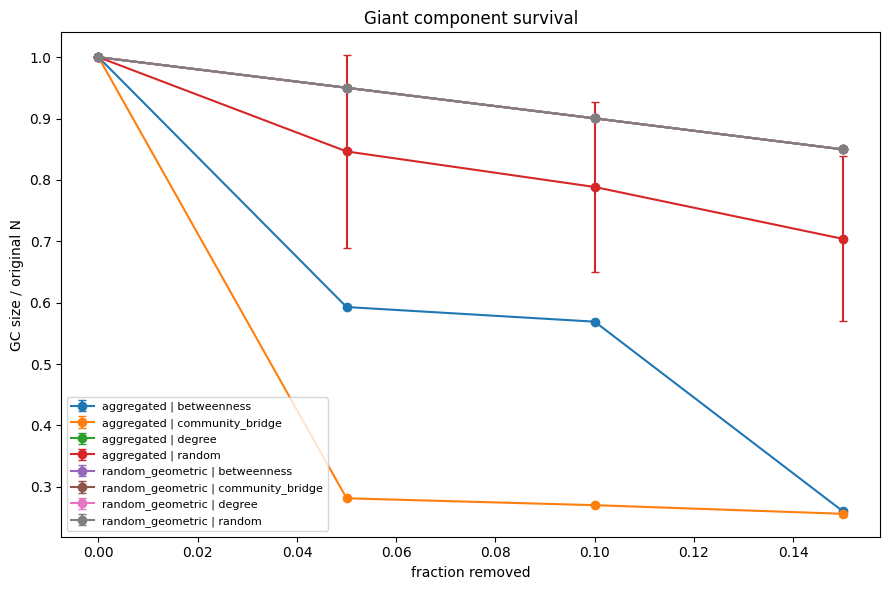

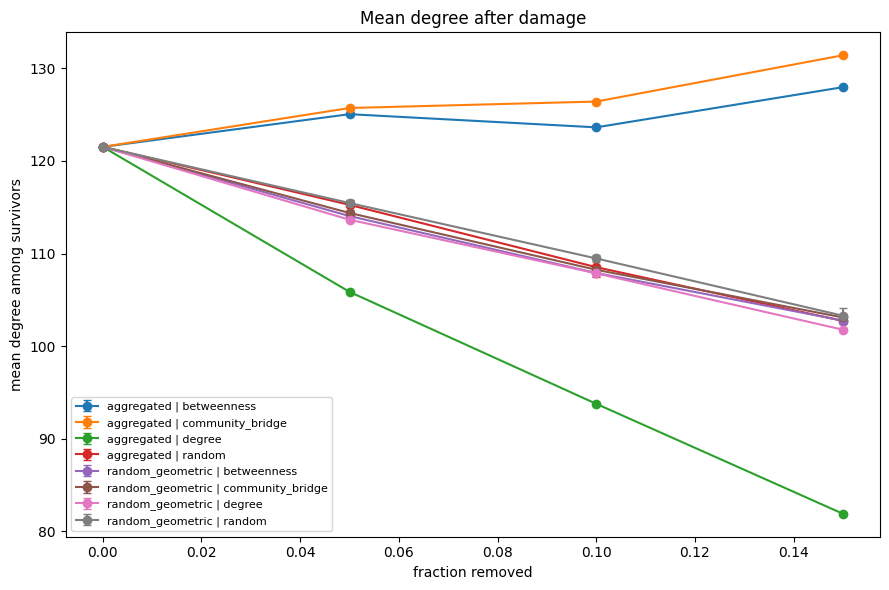

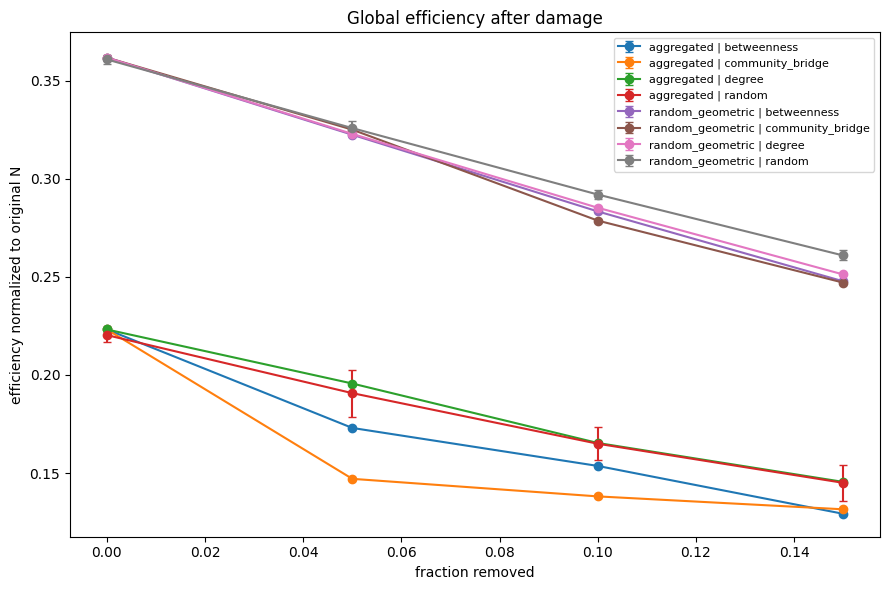

In [15]:
def summarize_results(df, metric):
    return (
        df.groupby(["network", "attack", "fraction_removed"], as_index=False)[metric]
        .agg(mean="mean", std="std")
    )


def plot_metric(df, metric, ylabel=None, title=None):
    summary = summarize_results(df, metric)
    plt.figure(figsize=(9, 6))

    for (network, attack), sub in summary.groupby(["network", "attack"]):
        sub = sub.sort_values("fraction_removed")
        plt.errorbar(
            sub["fraction_removed"],
            sub["mean"],
            yerr=sub["std"].fillna(0),
            marker="o",
            capsize=3,
            label=f"{network} | {attack}",
        )

    plt.xlabel("fraction removed")
    plt.ylabel(ylabel or metric)
    plt.title(title or metric)
    plt.legend(fontsize=8)
    plt.tight_layout()
    plt.show()


plot_metric(results, "gc_fraction_original", "GC size / original N", "Giant component survival")
plot_metric(results, "mean_degree", "mean degree among survivors", "Mean degree after damage")
plot_metric(results, "global_efficiency_original_norm", "efficiency normalized to original N", "Global efficiency after damage")


# 11. Representative raster

This is for visual examples, not for the whole damage sweep.

The damage function preserves the original neuron order. Therefore if the baseline was ordered E first, I last, the damaged raster should still have surviving E neurons first and surviving I neurons last.

We have also added a raster by communities. It would also be nice that we can get from here the functional aggregate.


Surviving cell types: (array(['E', 'I'], dtype='<U1'), array([794, 199]))
First 10 types: ['E' 'E' 'E' 'E' 'E' 'E' 'E' 'E' 'E' 'E']
Last 10 types: ['I' 'I' 'I' 'I' 'I' 'I' 'I' 'I' 'I' 'I']
{'network': 'aggregated', 'attack': 'degree', 'fraction_removed': 0, 'repeat': 0, 'n_original': 993, 'n_surviving': 993, 'n_edges': 16995, 'density': 0.03450565247051944, 'mean_degree': np.float64(34.229607250755286), 'average_clustering': 0.42647596880805244, 'n_components': 1, 'gc_size': 993, 'gc_fraction_surviving': 1.0, 'gc_fraction_original': 1.0, 'global_efficiency_surviving': 0.2054756309159031, 'global_efficiency_original_norm': 0.2054756309159031}
Activity: {'n_spikes': 25683, 'mean_firing_rate_hz': 8.62134944612286, 'active_fraction': 0.9144008056394763, 'population_rate_cv': np.float64(2.467198760954848)}


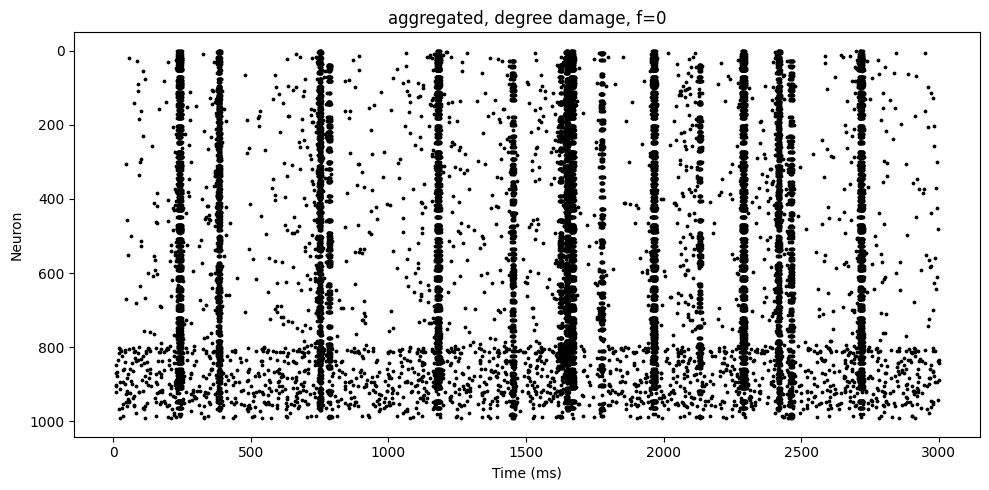

Original number of spikes: 25683
Community raster number of spikes: 25683
Original neuron min/max: 0 992
Community neuron min/max: 0 991


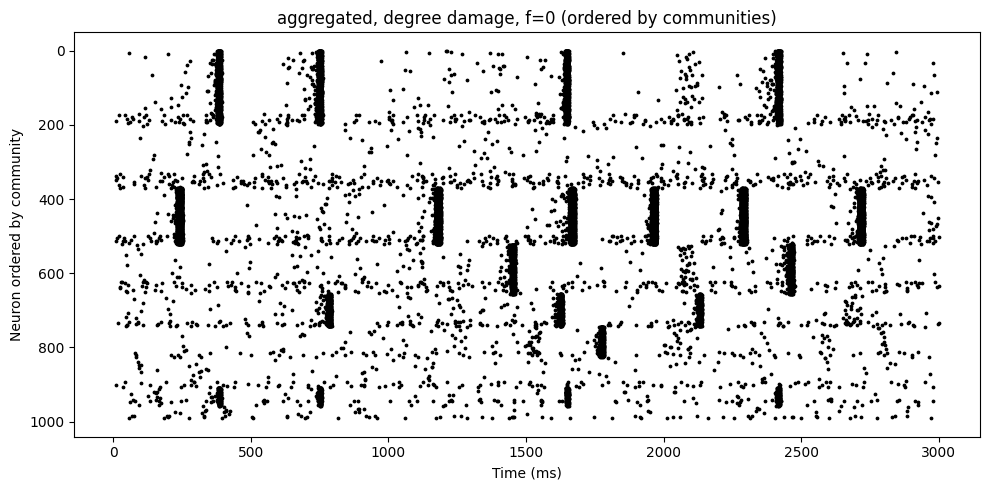

Number of communities: 10
Largest community sizes: [199, 172, 152, 134, 87, 83, 81, 50, 30, 5]


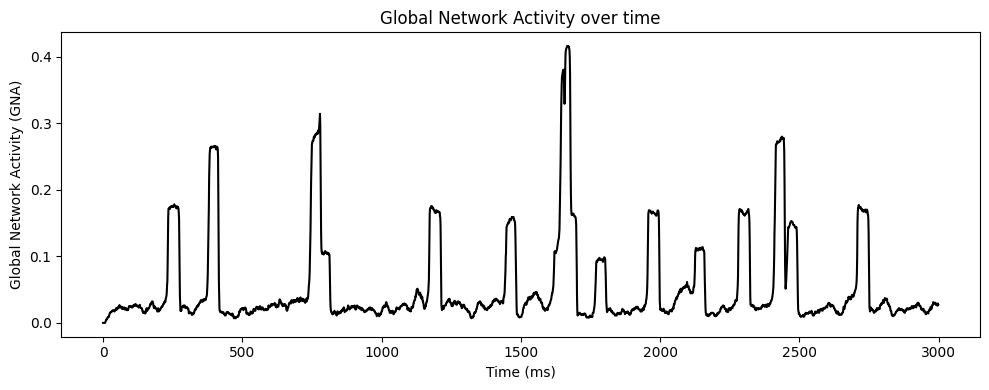

In [49]:
def simulate_and_plot_case(network="aggregated", attack="degree", fraction_removed=0.2, seed=SEED):
    if network == "aggregated":
        A0, types0, pos0 = A_agg, cell_types_agg, positions_agg
    elif network == "random_geometric":
        A0, types0, pos0 = A_rgg, cell_types_rgg, positions_rgg
    else:
        raise ValueError("network must be 'aggregated' or 'random_geometric'")

    order = None if attack == "random" else attack_orders[network][attack]

    A_dmg, types_dmg, pos_dmg, survivors, removed = damage_network(
        A0, types0, pos0,
        fraction_removed=fraction_removed,
        attack=attack,
        order=order,
        seed=seed,
    )

    print("Surviving cell types:", np.unique(types_dmg, return_counts=True))
    print("First 10 types:", types_dmg[:10])
    print("Last 10 types:", types_dmg[-10:])
    print(structural_metrics(A_dmg, A0.shape[0], network, attack, fraction_removed, seed=seed))

    firings = simulate_izhikevich_from_adjacency(
        A_dmg,
        types_dmg,
        sim_time=SIM_TIME,
        seed=seed,
        max_exc_weight=MAX_EXC_WEIGHT,
        max_inh_weight=MAX_INH_WEIGHT,
        noise_exc=NOISE_EXC,
        noise_inh=NOISE_INH,
    )

    print("Activity:", activity_metrics(firings, A_dmg.shape[0], SIM_TIME, BIN_SIZE))
    plot_raster(firings, cell_types=types_dmg,
                title=f"{network}, {attack} damage, f={fraction_removed}")
    plot_raster_by_communities(
    firings,
    A_dmg,
    title=f"{network}, {attack} damage, f={fraction_removed} (ordered by communities)",
    seed=SEED,
    show_boundaries=False
    )
    return A_dmg, types_dmg, pos_dmg, firings


# Example. Change these values as needed.
A_demo, types_demo, pos_demo, firings_demo = simulate_and_plot_case(
    network="aggregated",
    attack="degree",
    fraction_removed=0,
    seed=SEED,
)

def compute_GNA_from_raster(firings_t, firings_i, N, SIM_TIME, W=25):
    
    firings_t = np.asarray(firings_t, dtype=int)
    firings_i = np.asarray(firings_i, dtype=int) - 1  # 0-based
    
    # Para cada neurona, guardamos el último tiempo en que disparó
    last_spike = -np.inf * np.ones(N)
    
    GNA = np.zeros(SIM_TIME)
    active_count = 0
    
    # Ordenar por tiempo (importante)
    order = np.argsort(firings_t)
    firings_t = firings_t[order]
    firings_i = firings_i[order]
    
    idx = 0
    
    for t in range(1, SIM_TIME + 1):
        
        # Añadir spikes en este tiempo
        while idx < len(firings_t) and firings_t[idx] == t:
            neuron = firings_i[idx]
            
            # Si estaba inactiva, ahora cuenta
            if last_spike[neuron] < t - W:
                active_count += 1
            
            last_spike[neuron] = t
            idx += 1
        
        # Quitar neuronas que han dejado de estar activas
        active_count = np.sum(last_spike >= t - W)
        
        GNA[t-1] = active_count / N
    
    return GNA

GNA = compute_GNA_from_raster(firings_demo[:, 0], firings_demo[:, 1], A_demo.shape[0], SIM_TIME, W=25)
plt.figure(figsize=(10, 4))
plt.plot(GNA, color="black")
plt.xlabel("Time (ms)")
plt.ylabel("Global Network Activity (GNA)")
plt.title("Global Network Activity over time")
plt.tight_layout()
plt.show()

# Now let's try to find the functional 

In [ ]:

from scipy.signal import find_peaks

def binarize_functional_matrix(F, percentile=90):
    """
    Binariza una matriz funcional F utilizando un umbral basado en percentiles.

    Procedimiento:
    1. Se ignora la diagonal (autoconexiones) asignando NaN.
    2. Se consideran solo los valores de la parte triangular superior
       (para evitar duplicados en matrices simétricas).
    3. Se calcula un umbral como el percentil indicado (por defecto, 90).
       → El percentil p es el valor por debajo del cual se encuentra el p% de los datos.
    4. Se construye una matriz binaria donde:
       - 1 si F_ij >= threshold (conexiones más fuertes)
       - 0 en caso contrario
    5. Se simetriza la matriz para obtener una red no dirigida.
    6. Se eliminan autoconexiones (diagonal = 0).

    Interpretación:
    - Con percentile=90, se conservan aproximadamente el 10% de las conexiones más fuertes.
    - El umbral es relativo a la distribución de F, por lo que controla la densidad
      de la red de forma adaptativa.

    Parámetros
    ----------
    F : ndarray
        Matriz funcional (por ejemplo, correlaciones).
    percentile : float
        Percentil usado para definir el umbral (0–100).

    Returns
    -------
    F_binary : ndarray
        Matriz binaria (0/1) de conectividad.
    threshold : float
        Valor del umbral aplicado.
    """
    F_tmp = F.copy()
    np.fill_diagonal(F_tmp, np.nan)

    iu = np.triu_indices_from(F_tmp, k=1)
    vals = F_tmp[iu]
    valid_vals = vals[~np.isnan(vals)]
    F_binary = np.zeros_like(F, dtype=np.uint8)

    # threshold = np.percentile(valid_vals, percentile)
    # F_binary[iu] = (F[iu] >= threshold).astype(np.uint8)

    threshold = np.percentile(np.abs(valid_vals), percentile)
    F_binary[iu] = (np.abs(F[iu]) >= threshold).astype(np.uint8)

    F_binary = F_binary + F_binary.T
    np.fill_diagonal(F_binary, 0)

    return F_binary, threshold

def order_F_louvain_from_raster(
    F,
    F_binary,
    firings_i,
    seed=0
):
    N = F.shape[0]

    firings_i = firings_i.astype(int)

    # Detectar si las neuronas vienen como 1..N o como 0..N-1
    if firings_i.min() >= 1 and firings_i.max() <= N:
        active = np.unique(firings_i - 1)
    else:
        active = np.unique(firings_i)

    # Por seguridad, eliminar índices fuera de rango
    active = active[(active >= 0) & (active < N)]

    all_neurons = np.arange(N)
    inactive = np.setdiff1d(all_neurons, active)

    print(f"Neuronas activas: {len(active)}")
    print(f"Neuronas inactivas: {len(inactive)}")
    print(f"N total: {N}")
    print(f"activas + inactivas: {len(active) + len(inactive)}")

    W_active = F_binary[np.ix_(active, active)].copy()
    np.fill_diagonal(W_active, 0)

    G = nx.from_numpy_array(W_active)

    communities = nx.community.louvain_communities(
        G,
        weight="weight",
        resolution=1.0,
        seed=seed
    )

    communities = sorted(communities, key=len, reverse=True)

    degree = np.sum(W_active, axis=1)

    order_active_local = []

    for comm in communities:
        comm = list(comm)

        comm_sorted = sorted(
            comm,
            key=lambda i: degree[i],
            reverse=True
        )

        order_active_local.extend(comm_sorted)

    order_active_local = np.array(order_active_local, dtype=int)

    # Pasar de índices locales dentro de active a índices globales
    order_active = active[order_active_local]

    # Añadir cualquier activa que por lo que sea no haya entrado en comunidades
    missing_active = np.setdiff1d(active, order_active)
    order_active = np.concatenate([order_active, missing_active])

    # Orden final: activas primero, inactivas al final
    final_order = np.concatenate([order_active, inactive])

    print(f"Longitud final_order: {len(final_order)}")

    F_ordered = F[np.ix_(final_order, final_order)].copy()
    np.fill_diagonal(F_ordered, 0)

    return F_ordered, final_order, communities

def build_temporal_neuron_series(firings_t, firings_i, time_window=25, SIM_TIME = 5000, N=1000):

    # data = np.loadtxt(filename, skiprows=1)
    # firings_t = data[:, 0].astype(int)
    # firings_i = data[:, 1].astype(int)

    times = np.arange(0, SIM_TIME, time_window)

    # Quiero pasar de (t,i) a una matriz M de tamaño (len(times), N) donde M[j,n] = 1 si la neurona n ha disparado al menos una vez en el intervalo [times[j], times[j]+time_window)    
    M = np.zeros((len(times), N), dtype=np.uint8)

    for t, neuron_id in zip(firings_t, firings_i):

        row = t // time_window
        col = neuron_id - 1  # neuronas de 1..N a índices de 0..N-1

        if neuron_id < 1 or neuron_id > N:
            continue
        if row >= len(times):
            continue

        M[row, col] = 1

    return M, times


def build_F_matrix(firings_t, firings_i, SIM_TIME=5000, N=1000):
    M, times = build_temporal_neuron_series(
        firings_t,
        firings_i,
        time_window=25,
        SIM_TIME=SIM_TIME,
        N=N
    )

    F = np.corrcoef(M, rowvar=False)

    # Neuronas con actividad constante producen NaN en la correlación
    F = np.nan_to_num(F, nan=0.0, posinf=0.0, neginf=0.0)

    np.fill_diagonal(F, 0)

    F_binary, threshold = binarize_functional_matrix(F, percentile=90)

    F_ordered, order, communities = order_F_louvain_from_raster(
        F,
        F_binary,
        firings_i,
        seed=0
    )

    return F, F_binary, F_ordered, order, communities
def find_GNA_peaks(GNA):

    prom = 0.2 * np.std(GNA)

    peaks, properties = find_peaks(
        GNA,
        prominence=prom,  # prominencia mínima del pico
        height = 0.05,
        distance=20
    )

    peak_heights = properties.get("peak_heights", GNA[peaks] if len(peaks) > 0 else np.array([]))

    if len(peak_heights) == 0:
        mean_peak_height = 0.0
        std_peak_height = 0.0
    else:
        mean_peak_height = peak_heights.mean()
        std_peak_height = peak_heights.std()
    
    return peaks, peak_heights, mean_peak_height, std_peak_height

Neuronas activas: 908
Neuronas inactivas: 85
N total: 993
activas + inactivas: 993
Longitud final_order: 993


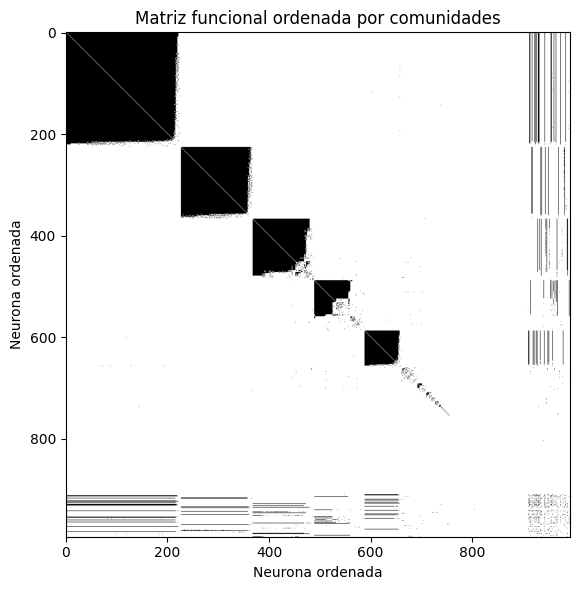

In [56]:
F, F_binary, F_ordered, order, communities = build_F_matrix(
    firings_t=firings_demo[:, 0],
    firings_i=firings_demo[:, 1],
    SIM_TIME=SIM_TIME,
    N=A_demo.shape[0]
)
F_binary = F_binary[np.ix_(order, order)]
plt.figure(figsize=(8, 6))
plt.imshow(
    F_binary,
    cmap="binary",
    aspect="equal",
    origin="upper",
    vmin=0,
    vmax=1
)
# plt.colorbar(label="Correlation")
plt.title("Matriz funcional ordenada por comunidades")
plt.xlabel("Neurona ordenada")
plt.ylabel("Neurona ordenada")
plt.tight_layout()
plt.show()

In [21]:
def spike_train_matrix(firings, N, sim_time, bin_size=10, binary=True):
    """
    Convert raster firings into a neuron x time-bin matrix.

    firings[:, 0] = spike time in ms
    firings[:, 1] = neuron index

    X[i, t] = activity of neuron i in time bin t
    """

    n_bins = int(np.ceil(sim_time / bin_size))
    X = np.zeros((N, n_bins), dtype=float)

    if firings.size == 0:
        return X

    times = firings[:, 0].astype(int)
    neurons = firings[:, 1].astype(int)

    bins = times // bin_size

    valid = (
        (neurons >= 0) &
        (neurons < N) &
        (bins >= 0) &
        (bins < n_bins)
    )

    neurons = neurons[valid]
    bins = bins[valid]

    for neuron, b in zip(neurons, bins):
        X[neuron, b] += 1

    if binary:
        X = (X > 0).astype(float)

    return X

def functional_correlation_from_raster(
    firings,
    N,
    sim_time,
    bin_size=10,
    binary=True,
):
    """
    Compute whole-train neuron-neuron correlation matrix.

    Each neuron is represented by its full binned spike train.
    Correlations are computed over the entire simulation.
    """

    X = spike_train_matrix(
        firings=firings,
        N=N,
        sim_time=sim_time,
        bin_size=bin_size,
        binary=binary
    )

    # Remove neurons with no variance, because correlation is undefined.
    std = X.std(axis=1)
    valid_neurons = std > 0

    C = np.zeros((N, N), dtype=float)

    if valid_neurons.sum() < 2:
        return C, X, valid_neurons

    C_valid = np.corrcoef(X[valid_neurons])
    C_valid = np.nan_to_num(C_valid, nan=0.0, posinf=0.0, neginf=0.0)

    C[np.ix_(valid_neurons, valid_neurons)] = C_valid
    np.fill_diagonal(C, 0.0)

    return C, X, valid_neurons

def threshold_absolute_correlations(C, percentile=97):
    """
    Build a binary functional adjacency matrix by keeping only
    the strongest absolute correlations.
    """

    C_abs = np.abs(C).copy()
    np.fill_diagonal(C_abs, 0.0)

    values = C_abs[np.triu_indices_from(C_abs, k=1)]
    values = values[values > 0]

    if len(values) == 0:
        F = np.zeros_like(C_abs, dtype=int)
        return F, np.nan

    threshold = np.percentile(values, percentile)

    F = (C_abs >= threshold).astype(int)
    F = np.maximum(F, F.T)
    np.fill_diagonal(F, 0)

    return F, threshold


def plot_functional_adjacency(F, title="Functional adjacency", seed=42):
    F_ordered, communities, ordered_nodes = community_ordered_adjacency(F, seed=seed)

    plt.figure(figsize=(6, 6))
    plt.imshow(
        F_ordered,
        cmap="Greys",
        interpolation="nearest",
        origin="upper"
    )

    plt.xlabel("Neuron")
    plt.ylabel("Neuron")
    plt.title(title)
    plt.tight_layout()
    plt.show()

    print("Functional edges:", int(F.sum() // 2))
    print("Functional communities:", len(communities))
    print("Largest community sizes:", [len(c) for c in communities[:10]])

Correlation threshold: 0.6842438763262877
Functional edges: 40736
Functional density: 0.08270798817529156


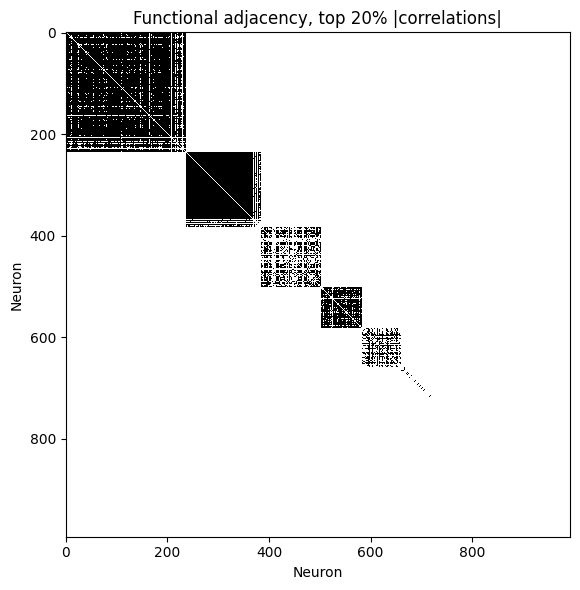

Functional edges: 40736
Functional communities: 280
Largest community sizes: [235, 148, 119, 81, 76, 9, 7, 5, 5, 5]


In [23]:
C_func, X_spikes, valid_neurons = functional_correlation_from_raster(
    firings=firings_demo,
    N=A_demo.shape[0],
    sim_time=SIM_TIME,
    bin_size=10,
    binary=True
)

F_func, corr_threshold = threshold_absolute_correlations(
    C_func,
    percentile=90
)

print("Correlation threshold:", corr_threshold)
print("Functional edges:", int(F_func.sum() // 2))
print("Functional density:", F_func.sum() / (F_func.shape[0] * (F_func.shape[0] - 1)))

plot_functional_adjacency(
    F_func,
    title=f"Functional adjacency, top {100 - 80}% |correlations|",
    seed=SEED
)

# 12. Save results

In [ ]:
OUT_DIR = Path("simple_damage_results")
OUT_DIR.mkdir(exist_ok=True)
results.to_csv(OUT_DIR / "structural_damage_results.csv", index=False)
print("Saved:", (OUT_DIR / "structural_damage_results.csv").resolve())
